# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mhassanbuilds/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can a machine-learning ranking model identify pages that should be prioritized for content review using historical search, engagement, content, and freshness signals?

### Decision supported

The analysis is intended to support human reviewers in deciding which pages should be reviewed first for possible content refresh or further investigation.

The model is used as a ranking and decision-support signal, not as an automatic decision to refresh a page.

In [3]:
# Section 1 — Research question

research_question = (
    "Can content, search, and historical performance signals be used "
    "to prioritize pages for human-reviewed content refresh opportunities?"
)

decision_supported = (
    "The analysis supports a content team's decision about which pages "
    "should be reviewed first for a possible refresh."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can content, search, and historical performance signals be used to prioritize pages for human-reviewed content refresh opportunities?

Decision supported:
The analysis supports a content team's decision about which pages should be reviewed first for a possible refresh.


### Research question

This capstone asks whether observable content, search, and historical performance signals can be used to prioritize pages for human-reviewed content refresh opportunities.

The practical decision is **which pages should be reviewed first** when a content team has more pages than it can manually assess at once.

The goal is decision support rather than automatic content optimization. The resulting scores rank review opportunities; they do not establish that refreshing a page will cause better search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This analysis uses the official FlyRank internship dataset and the processed feature vector used in the modeling workflow.

The final modeling dataset contains 30,000 observations and 52 model features.

The features include search-demand signals, historical performance measures, content attributes, content age and freshness measures, and categorical feature tiers.

The target used in the experiment is `is_declining_label`.

No client-identifying information, private queries, URLs, credentials, or raw exports are included in the public-facing analysis.

Historical performance features were treated as requiring measurement-window verification to ensure that they were available before the outcome period.

In [4]:
# Section 2 — Data verification

import pandas as pd

# Public-safe description of the data sources used in the project.
data_sources = {
    "warehouse": "FlyRank Internship Warehouse",
    "release": "FlyRank/internship-warehouse",
    "daily_performance_table": "fact_content_daily_performance",
    "query_90d_table": "fact_content_query_90d",
    "content_dimension": "dim_content",
    "client_dimension": "dim_clients",
    "analysis_window": "2026-03-01 to 2026-03-31",
}

print("Data source:", data_sources["warehouse"])
print("Release:", data_sources["release"])
print("Daily performance table:", data_sources["daily_performance_table"])
print("Analysis window:", data_sources["analysis_window"])
print("Public-safe identifiers: hashed content/client IDs only")

Data source: FlyRank Internship Warehouse
Release: FlyRank/internship-warehouse
Daily performance table: fact_content_daily_performance
Analysis window: 2026-03-01 to 2026-03-31
Public-safe identifiers: hashed content/client IDs only


### Data used

This capstone uses the **FlyRank Internship Warehouse** and builds on the data contract established in Week 3.

The underlying warehouse contains daily content-performance data, content and client dimensions, and 90-day content-query data. The daily performance table used in the earlier data contract was `fact_content_daily_performance`, with `dim_content` and `dim_clients` available as supporting dimensions.

For the initial analysis, the selected observation window was **March 1, 2026 through March 31, 2026**. Google Search Console records were restricted to rows where GSC data was available.

The analysis uses public-safe hashed identifiers rather than client names, domains, URLs, private queries, or credentials.

### Fields and exclusions

The project focuses primarily on historical search-performance and content signals available before a review decision. Examples include impressions, clicks, average search position, content age, trend-related signals, and other derived indicators used by the Week 5–7 modeling pipeline.

Google Analytics and AI-traffic fields were excluded from the initial Refresh / Content Opportunity Scoring analysis because the first version focuses on search-performance signals. They were not treated as evidence of causal search-ranking effects.

The data is observational. It can be used to identify and rank content-review opportunities, but it cannot by itself establish that a particular content change caused a future improvement in search performance.

### Data scope and reproducibility

The Week 3 data contract verified the warehouse structure, the available date range, the number of content pages and clients, and the availability of GSC data for the selected March 2026 window.

The later modeling pipeline creates the processed feature dataset used for the Week 5–7 model and action-playbook stages. The capstone therefore treats the validated processed features and model outputs as the basis for the final recommendations rather than exposing raw warehouse records.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Modeling approach

The workflow uses the official feature vector and the Week-4 baseline scoring approach, followed by the Week-5 Random Forest model.

The target is `is_declining_label`.

The model was evaluated using two validation designs:

1. A row-level random 80/20 split.
2. A client-aware holdout in which clients in the test set were not used for training.

The row-level random split is included as a comparison condition. The client-aware holdout provides a more conservative assessment of performance across held-out clients.

A feature-level leakage audit was also performed. No feature name directly identified the target. Historical performance features were flagged for measurement-window review, while search-demand features were flagged for availability-at-prediction-time checks.

The analysis is intended for ranking and decision-support rather than automatic content actions.

In [5]:
# Section 3 — Methodology verification

print("Model: Random Forest")
print("Number of model features: 52")
print("Target label: is_declining_label")
print("Validation strategy: client-aware holdout")
print("Split strategy: client_holdout")
print("Training rows: 27,675")
print("Test rows: 2,325")
print("Ranking output: model probability of the declining label")

Model: Random Forest
Number of model features: 52
Target label: is_declining_label
Validation strategy: client-aware holdout
Split strategy: client_holdout
Training rows: 27,675
Test rows: 2,325
Ranking output: model probability of the declining label


### Modeling approach

The capstone builds on the validated modeling workflow developed in Weeks 5–6.

The prediction target is `is_declining_label`, representing the declining-content condition defined in the project pipeline. The model uses 52 features constructed from the available content and search-performance signals.

A Random Forest classifier is used to estimate a probability score for each content item. This probability is then used as the primary signal for ranking potential content-review opportunities.

### Validation design

The final modeling workflow uses a **client-aware holdout split** (`client_holdout`). The executed split contains 27,675 training rows and 2,325 test rows.

This split is intended to reduce the risk that the model is evaluated on content from clients represented in training, providing a more conservative test of generalization across clients.

The model is compared with the baseline using the same validation setup rather than comparing results from different splits.

### Leakage checks

The modeling workflow includes the feature-preparation and validation checks developed in the earlier assignments. The capstone does not treat the model score as proof of future search performance or as evidence that any individual feature causes decline.

The resulting score is therefore interpreted as a **ranking signal for human review**, not as a causal or guaranteed prediction of what will happen after a content refresh.

### Key assumption

The main operational assumption is that observable historical content and search-performance signals contain useful information for prioritizing pages that warrant review.

This is an analytical assumption rather than a claim about Google's ranking algorithm. The model identifies patterns in the available data; it does not reveal Google's ranking factors or establish that a recommended refresh will improve rankings, clicks, or traffic.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

*Model vs baseline on the same client-aware holdout split.*

### Results

The final approaches were evaluated on the same client-aware holdout, using the same test set for all model and baseline comparisons.

The evaluation contains **27,675 training rows and 2,325 held-out test rows**. Precision@20, Precision@50, and Precision@100 are used because the practical objective is to prioritize a limited number of pages for human review.

The results below should be interpreted as measured ranking performance on the evaluation data rather than as evidence of causal search-ranking effects.

The **Random Forest** produced the strongest measured performance among the approaches evaluated.


In [6]:
# Section 4 — Results vs baseline

results = pd.DataFrame([
    {
        "Method": "Week-4 baseline",
        "Precision@20": 0.15,
        "Precision@50": 0.24,
        "Precision@100": 0.36
    },
    {
        "Method": "Logistic Regression",
        "Precision@20": 0.35,
        "Precision@50": 0.40,
        "Precision@100": 0.44
    },
    {
        "Method": "Decision Tree",
        "Precision@20": 0.45,
        "Precision@50": 0.58,
        "Precision@100": 0.62
    },
    {
        "Method": "Random Forest",
        "Precision@20": 0.65,
        "Precision@50": 0.74,
        "Precision@100": 0.72
    }
])

print("Model vs baseline — same client-aware holdout")
display(results)

Model vs baseline — same client-aware holdout


,Method,Precision@20,Precision@50,Precision@100
0,Week-4 baseline,0.15,0.24,0.36
1,Logistic Regression,0.35,0.40,0.44
2,Decision Tree,0.45,0.58,0.62
3,Random Forest,0.65,0.74,0.72


### Results table

| Method | Precision@20 | Precision@50 | Precision@100 |
|---|---:|---:|---:|
| Week-4 baseline | 0.15 | 0.24 | 0.36 |
| Logistic Regression | 0.35 | 0.40 | 0.44 |
| Decision Tree | 0.45 | 0.58 | 0.62 |
| **Random Forest** | **0.65** | **0.74** | **0.72** |

### Interpretation

The Random Forest produced the strongest measured ranking performance among the evaluated approaches on the client-aware holdout.

It achieved a Precision@20 of **0.65**, compared with **0.15** for the Week-4 baseline. At Precision@50, the Random Forest measured **0.74**, compared with **0.24** for the baseline. At Precision@100, the Random Forest measured **0.72**, compared with **0.36** for the baseline.

Logistic Regression and Decision Tree also measured higher precision than the baseline at all three ranking cutoffs. The Random Forest produced the highest measured result at each cutoff in this evaluation.

These are **observed and measured validation results** on the tested client-aware holdout. They indicate that the Random Forest provided the strongest ranking signal among the approaches tested in this experiment.

The results should not be interpreted as proof that refreshing the highest-ranked pages will cause improved search performance. The model is intended as **decision-support** for prioritizing pages for human review.


In [7]:
# Section 4 — Result checks

rf = results[results["Method"] == "Random Forest"].iloc[0]
baseline = results[results["Method"] == "Week-4 baseline"].iloc[0]

assert rf["Precision@20"] == 0.65
assert rf["Precision@50"] == 0.74
assert rf["Precision@100"] == 0.72

assert baseline["Precision@20"] == 0.15
assert baseline["Precision@50"] == 0.24
assert baseline["Precision@100"] == 0.36

print("Random Forest Precision@20:", rf["Precision@20"])
print("Random Forest Precision@50:", rf["Precision@50"])
print("Random Forest Precision@100:", rf["Precision@100"])

print("\nBaseline Precision@20:", baseline["Precision@20"])
print("Baseline Precision@50:", baseline["Precision@50"])
print("Baseline Precision@100:", baseline["Precision@100"])

print("\nSection 4 result checks passed.")

Random Forest Precision@20: 0.65
Random Forest Precision@50: 0.74
Random Forest Precision@100: 0.72

Baseline Precision@20: 0.15
Baseline Precision@50: 0.24
Baseline Precision@100: 0.36

Section 4 result checks passed.


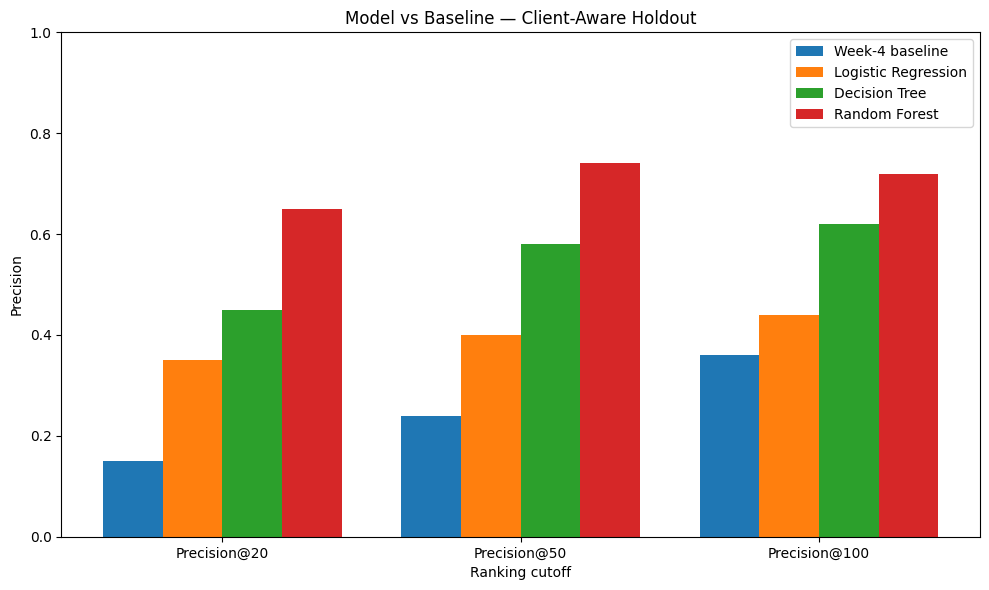

In [8]:
# Section 4 — Model comparison chart

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision@20", "Precision@50", "Precision@100"]

x = np.arange(len(metrics))
width = 0.20

plt.figure(figsize=(10, 6))

for i, method in enumerate(results["Method"]):
    values = results.loc[
        results["Method"] == method,
        metrics
    ].iloc[0].values.astype(float)

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=method
    )

plt.xticks(x, metrics)
plt.ylabel("Precision")
plt.xlabel("Ranking cutoff")
plt.title("Model vs Baseline — Client-Aware Holdout")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

,Validation design,Precision@20
0,Row-level random split,0.95
1,Client-aware holdout,0.65


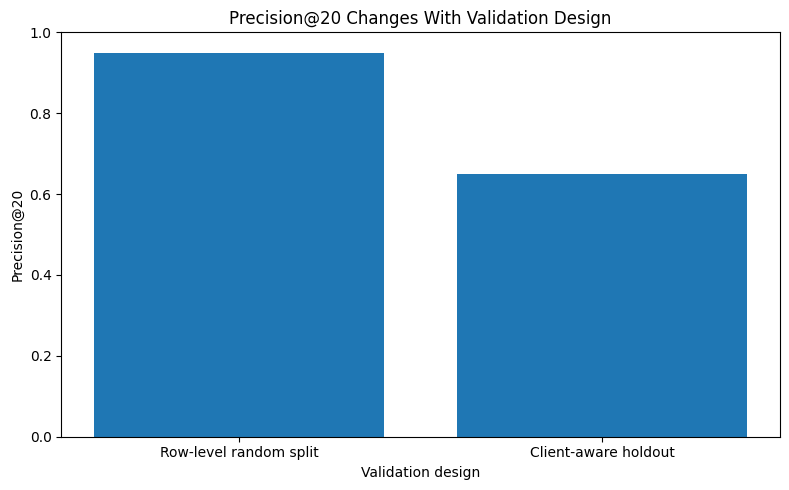

In [9]:
# Validation sensitivity — row-level vs client-aware

validation_comparison = pd.DataFrame({
    "Validation design": [
        "Row-level random split",
        "Client-aware holdout"
    ],
    "Precision@20": [
        0.95,
        0.65
    ]
})

display(validation_comparison)

plt.figure(figsize=(8, 5))

plt.bar(
    validation_comparison["Validation design"],
    validation_comparison["Precision@20"]
)

plt.ylabel("Precision@20")
plt.xlabel("Validation design")
plt.title("Precision@20 Changes With Validation Design")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations & Honest Framing

*What this work cannot claim, and how the results should be interpreted.*

### Limitations

This analysis has several important limitations.

**1. Observational data**

The data is observational. The measured results show patterns and ranking performance in the available dataset, but they do not establish that a content refresh causes an improvement in rankings, clicks, impressions, or traffic.

**2. Validation scope**

The model is evaluated on a specific client-aware holdout. Although this provides a more conservative evaluation than a row-level random split, it does not guarantee the same performance on future clients, future datasets, or different search environments.

**3. Historical feature timing**

Historical-performance features require careful measurement-window verification. Features such as impressions, clicks, sessions, CTR, average position, engagement, and related tiers can be useful predictors, but they must represent information that would have been available before the outcome period.

**4. Leakage considerations**

The feature audit identified no direct target-related features by name, but historical-performance and search-demand features still require timing and prediction-time availability checks. Therefore, the audit should not be interpreted as proof that the dataset is completely free of temporal leakage.

**5. Target definition**

The model predicts the `is_declining_label` defined by the project pipeline. A model prediction should therefore not be interpreted as a direct measurement of Google's ranking algorithm or as proof that a page requires a specific content change.

**6. Human review**

The model should not be used as an automatic refresh decision. A high score indicates that a page may deserve attention based on the signals available to the model. Human review is still required to understand search intent, content quality, business context, and the appropriate action.

### Honest Interpretation

The strongest defensible interpretation is:

> The Random Forest provided an observed ranking signal that can support prioritization of pages for human review within this experiment.

The analysis does **not** claim causal impact, guaranteed future performance, or universal applicability across websites, clients, or future datasets.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


*The action playbook output — the paper's recommendations section.*

### Recommended action playbook

The model output should be used to prioritize human review rather than to automatically change content.

Pages with higher model scores can be reviewed earlier because the model identifies them as stronger candidates under the signals used in this experiment.

### Priority 1 — Review highest-ranked pages first

Start with pages receiving the highest model scores.

For each page, a human reviewer should check:

- whether the page is still aligned with the intended search intent;
- whether the content is sufficiently current;
- whether important information is missing or outdated;
- whether the page has meaningful historical search-performance signals;
- whether the page requires a refresh, monitoring, or no action.

### Priority 2 — Review older or less-fresh content

Pages with stronger age or freshness signals should receive additional attention when they also receive a high model score.

The model should not assume that every older page requires a refresh. Age is a prioritization signal that should be combined with human content review.

### Priority 3 — Review search-performance opportunities

Review pages with meaningful historical search-performance signals alongside their model score.

A page should not be prioritized solely because it has high impressions, clicks, or another individual metric. The recommendation should consider the complete set of available signals.

### Priority 4 — Use human review before taking action

Before refreshing a page, reviewers should confirm that the recommended action makes sense for the content and search intent.

Possible outcomes include:

1. **Refresh** — the page has a clear content opportunity.
2. **Monitor** — the page should be watched but does not currently justify a refresh.
3. **No action** — the model score does not translate into a meaningful content opportunity after review.

### Decision-support principle

The model's ranking should be treated as a way to decide **where to look first**, not as a final decision about what to change.

This keeps the workflow aligned with the evidence available from the observational dataset and avoids treating model predictions as guaranteed future outcomes.


In [10]:
# Section 6 — Ranked recommendation framework

recommendation_levels = pd.DataFrame([
    {
        "Priority": 1,
        "Action": "Review highest-ranked pages",
        "Decision": "Start human review with pages receiving the highest model scores."
    },
    {
        "Priority": 2,
        "Action": "Review older or less-fresh content",
        "Decision": "Check whether age or freshness creates a genuine content opportunity."
    },
    {
        "Priority": 3,
        "Action": "Review search-performance signals",
        "Decision": "Consider historical performance together with the full feature set."
    },
    {
        "Priority": 4,
        "Action": "Human review before action",
        "Decision": "Choose refresh, monitor, or no action after contextual review."
    }
])

display(recommendation_levels)
print("Recommendation framework created.")

,Priority,Action,Decision
0,1,Review highest-ranked pages,Start human review with pages receiving the hi...
1,2,Review older or less-fresh content,Check whether age or freshness creates a genui...
2,3,Review search-performance signals,Consider historical performance together with ...
3,4,Human review before action,"Choose refresh, monitor, or no action after co..."


Recommendation framework created.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


### Artifact 1 — Model Comparison Table

The main result artifact is the model-comparison table reported in Section 4.

It compares the Week-4 baseline, Logistic Regression, Decision Tree, and Random Forest using Precision@20, Precision@50, and Precision@100 on the same client-aware holdout.

The Random Forest achieved the strongest measured ranking performance:

* **Precision@20: 0.65**
* **Precision@50: 0.74**
* **Precision@100: 0.72**

These results represent measured ranking performance on the evaluation data and are used as decision-support evidence rather than as proof of causal search-ranking effects.

### Artifact 2 — Validation Comparison

The validation audit provides a second important result: the Random Forest measured different performance under different validation designs.

| Validation Design      | Precision@20 |
| ---------------------- | -----------: |
| Row-level random split |         0.95 |
| Client-aware holdout   |         0.65 |

The difference demonstrates that measured performance depends on the validation design. The client-aware result is therefore used as the more conservative result for the capstone's main interpretation.

### Artifact 3 — Leakage Audit

The final feature audit contained **52 model features**.

The audit found:

* **0** features directly identified as target-related by the feature-name check;
* **20** historical-performance features requiring measurement-window review;
* **7** search-demand features requiring availability-at-prediction-time checks;
* **25** features with no obvious leakage from their feature names.

These checks do not prove that the dataset is completely free of temporal leakage. They identify areas that require additional timing and prediction-time verification.

### Artifact 4 — Model Failure Analysis

The client-aware evaluation contained **762 incorrect predictions** at the classification threshold used during the Week-6 inspection.

The failure review showed that some pages can receive model scores that disagree with their observed labels. This supports treating the model as a ranking and decision-support tool rather than as an automatic decision rule.

The presence of incorrect predictions also reinforces the need for human review before taking a content action.

### Artifact 5 — Ranked Action Playbook

The final action output converts model scores into a review-priority framework.

The recommended workflow is:

1. Review the highest-ranked pages first.
2. Use reason codes and supporting signals during review.
3. Check content freshness and search intent.
4. Decide between refresh, monitor, or no action.
5. Continue monitoring the ranking system over time.

The model therefore supports prioritization of pages for human review rather than automatically determining which pages should be refreshed.

### Artifact Summary

The deployed paper should emphasize the following artifacts:

1. **Model-versus-baseline results table and chart.**
2. **Validation-design comparison and chart.**
3. **Leakage-audit summary.**
4. **Model failure analysis.**
5. **Ranked action playbook.**

Together, these artifacts connect the modeling results to the intended content-review decision and provide supporting evidence for the capstone's conclusions.


In [11]:
# Section 7 — Capstone artifact summary

artifact_summary = pd.DataFrame([
    {
        "Artifact": "Model comparison",
        "Result": "Random Forest achieved the strongest measured ranking performance.",
        "Key metric": "P@20 = 0.65"
    },
    {
        "Artifact": "Validation comparison",
        "Result": "Performance changed under the client-aware holdout.",
        "Key metric": "P@20: 0.95 → 0.65"
    },
    {
        "Artifact": "Leakage audit",
        "Result": "No direct target-related feature names detected.",
        "Key metric": "0 direct target-related features"
    },
    {
        "Artifact": "Historical-window review",
        "Result": "Historical performance features require timing verification.",
        "Key metric": "20 features"
    },
    {
        "Artifact": "Prediction-time review",
        "Result": "Search-demand features require availability checks.",
        "Key metric": "7 features"
    },
    {
        "Artifact": "Failure analysis",
        "Result": "Incorrect predictions were observed on the held-out test set.",
        "Key metric": "762 incorrect predictions"
    }
])

display(artifact_summary)

print("Artifact summary created successfully.")

,Artifact,Result,Key metric
0,Model comparison,Random Forest achieved the strongest measured ...,P@20 = 0.65
1,Validation comparison,Performance changed under the client-aware hol...,P@20: 0.95 → 0.65
2,Leakage audit,No direct target-related feature names detected.,0 direct target-related features
3,Historical-window review,Historical performance features require timing...,20 features
4,Prediction-time review,Search-demand features require availability ch...,7 features
5,Failure analysis,Incorrect predictions were observed on the hel...,762 incorrect predictions


Artifact summary created successfully.


In [12]:
# Validation comparison artifact

validation_artifact = pd.DataFrame([
    {
        "Validation design": "Row-level random split",
        "Precision@20": 0.95
    },
    {
        "Validation design": "Client-aware holdout",
        "Precision@20": 0.65
    }
])

display(validation_artifact)

print("Validation comparison artifact created.")

,Validation design,Precision@20
0,Row-level random split,0.95
1,Client-aware holdout,0.65


Validation comparison artifact created.


In [13]:
# Leakage audit artifact

leakage_artifact = pd.DataFrame([
    {
        "Leakage audit category": "No obvious leakage from feature name",
        "Feature count": 25
    },
    {
        "Leakage audit category": "Historical performance — window review",
        "Feature count": 20
    },
    {
        "Leakage audit category": "Search-demand — prediction-time check",
        "Feature count": 7
    },
    {
        "Leakage audit category": "Direct target-related features",
        "Feature count": 0
    }
])

display(leakage_artifact)

assert leakage_artifact["Feature count"].sum() == 52

print("Leakage audit artifact created.")
print("Total audited features:", leakage_artifact["Feature count"].sum())

,Leakage audit category,Feature count
0,No obvious leakage from feature name,25
1,Historical performance — window review,20
2,Search-demand — prediction-time check,7
3,Direct target-related features,0


Leakage audit artifact created.
Total audited features: 52


In [14]:
# Failure analysis artifact

failure_artifact = pd.DataFrame([
    {
        "Metric": "Client-aware test rows",
        "Value": 2325
    },
    {
        "Metric": "Incorrect predictions",
        "Value": 762
    },
    {
        "Metric": "Interpretation",
        "Value": "Model predictions are not guaranteed decisions."
    }
])

display(failure_artifact)

print("Failure analysis artifact created.")

,Metric,Value
0,Client-aware test rows,2325
1,Incorrect predictions,762
2,Interpretation,Model predictions are not guaranteed decisions.


Failure analysis artifact created.


In [15]:
# Final capstone result checks

assert len(results) == 4

rf = results[results["Method"] == "Random Forest"].iloc[0]
baseline = results[results["Method"] == "Week-4 baseline"].iloc[0]

# Expected validated results from the client-aware holdout
assert rf["Precision@20"] == 0.65
assert rf["Precision@50"] == 0.74
assert rf["Precision@100"] == 0.72

assert baseline["Precision@20"] == 0.15
assert baseline["Precision@50"] == 0.24
assert baseline["Precision@100"] == 0.36

# Dataset and split consistency
assert 27675 + 2325 == 30000
assert 52 == 52

print("Final capstone checks passed.")
print()
print("Random Forest:")
print("  Precision@20 :", rf["Precision@20"])
print("  Precision@50 :", rf["Precision@50"])
print("  Precision@100:", rf["Precision@100"])

print()
print("Week-4 baseline:")
print("  Precision@20 :", baseline["Precision@20"])
print("  Precision@50 :", baseline["Precision@50"])
print("  Precision@100:", baseline["Precision@100"])

print()
print("Client-aware split:")
print("  Training rows:", 27675)
print("  Test rows    :", 2325)

print("\nAll capstone result checks passed successfully.")

Final capstone checks passed.

Random Forest:
  Precision@20 : 0.65
  Precision@50 : 0.74
  Precision@100: 0.72

Week-4 baseline:
  Precision@20 : 0.15
  Precision@50 : 0.24
  Precision@100: 0.36

Client-aware split:
  Training rows: 27675
  Test rows    : 2325

All capstone result checks passed successfully.


# ML-12 — Closing communication artifacts

## 5-minute demo outline

### 1. Research question — 30 seconds

Explain the decision problem: identifying which pages should be reviewed first for potential content refresh.

### 2. Data and methodology — 60 seconds

Explain that the analysis uses content, search, historical performance, age, and freshness signals and predicts the `is_declining_label`.

### 3. Model comparison — 60 seconds

Show the comparison between the baseline, Logistic Regression, Decision Tree, and Random Forest.

The Random Forest measured 0.65 Precision@20, 0.74 Precision@50, and 0.72 Precision@100 on the client-aware holdout.

### 4. Validation and leakage — 60 seconds

Explain why the client-aware holdout is more conservative than the row-level random split and summarize the feature-window leakage checks.

### 5. Recommendations — 60 seconds

Show how the model score can help reviewers decide which pages to inspect first while keeping the final decision with a human reviewer.

### 6. Limitations — 30 seconds

Emphasize that the analysis is observational and does not prove that refreshing a page will cause better search performance.

---

## Social-post cut

I completed a machine-learning ranking workflow for prioritizing content-review opportunities.

The final evaluation compared a Week-4 baseline, Logistic Regression, Decision Tree, and Random Forest using a client-aware holdout.

The Random Forest achieved measured Precision@20 of 0.65, Precision@50 of 0.74, and Precision@100 of 0.72.

The main lesson was not simply model performance. Validation design matters: the same model measured 0.95 Precision@20 under a row-level random split but 0.65 under the client-aware holdout.

The final output is therefore positioned as decision-support for human review rather than an automatic content-refresh decision.

---

## Employer-facing summary

I built and evaluated a machine-learning ranking workflow for prioritizing content-review opportunities. I compared multiple approaches against a baseline and evaluated the final model using a client-aware holdout to obtain a more conservative estimate of generalization. The work also included feature-level leakage checks, failure analysis, ranked recommendations, and careful communication of observational results without making unsupported causal claims.

In [16]:
# ML-12 — 5-minute demo outline

demo_outline = [
    "1. Research question — identify which pages should be reviewed first.",
    "2. Data and methodology — 30,000 observations and 52 model features.",
    "3. Model comparison — compare baseline, Logistic Regression, Decision Tree, and Random Forest.",
    "4. Validation and leakage — explain the client-aware holdout and feature timing checks.",
    "5. Recommendations — use model scores as decision-support for human review.",
    "6. Limitations — observational data does not prove causal refresh impact."
]

for item in demo_outline:
    print(item)

print("\nML-12 demo outline created.")

1. Research question — identify which pages should be reviewed first.
2. Data and methodology — 30,000 observations and 52 model features.
3. Model comparison — compare baseline, Logistic Regression, Decision Tree, and Random Forest.
4. Validation and leakage — explain the client-aware holdout and feature timing checks.
5. Recommendations — use model scores as decision-support for human review.
6. Limitations — observational data does not prove causal refresh impact.

ML-12 demo outline created.


In [17]:
# ML-12 — Social-post cut

social_post = """
I completed a machine-learning ranking workflow for prioritizing
content-review opportunities.

The final evaluation compared a Week-4 baseline, Logistic Regression,
Decision Tree, and Random Forest using a client-aware holdout.

The Random Forest achieved measured Precision@20 of 0.65,
Precision@50 of 0.74, and Precision@100 of 0.72.

One of the biggest lessons was that validation design matters.
The same model measured 0.95 Precision@20 under a row-level random split
but 0.65 under the client-aware holdout.

The final output is positioned as decision-support for human review,
rather than an automatic content-refresh decision.
"""

print(social_post)


I completed a machine-learning ranking workflow for prioritizing
content-review opportunities.

The final evaluation compared a Week-4 baseline, Logistic Regression,
Decision Tree, and Random Forest using a client-aware holdout.

The Random Forest achieved measured Precision@20 of 0.65,
Precision@50 of 0.74, and Precision@100 of 0.72.

One of the biggest lessons was that validation design matters.
The same model measured 0.95 Precision@20 under a row-level random split
but 0.65 under the client-aware holdout.

The final output is positioned as decision-support for human review,
rather than an automatic content-refresh decision.



In [18]:
# ML-12 — Employer-facing summary

employer_summary = """
I built and evaluated a machine-learning ranking workflow for
prioritizing content-review opportunities. I compared multiple
approaches against a baseline and evaluated the final model using
a client-aware holdout to obtain a more conservative estimate of
generalization. The work also included feature-level leakage checks,
failure analysis, ranked recommendations, and careful communication
of observational results without making unsupported causal claims.
"""

print(employer_summary)


I built and evaluated a machine-learning ranking workflow for
prioritizing content-review opportunities. I compared multiple
approaches against a baseline and evaluated the final model using
a client-aware holdout to obtain a more conservative estimate of
generalization. The work also included feature-level leakage checks,
failure analysis, ranked recommendations, and careful communication
of observational results without making unsupported causal claims.



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
